# 1 Set Up

In [1]:
import os
from dotenv import load_dotenv

# 1. Load the .env file from the specified path
custom_env_path = "/Users/daisy/Documents/LuoWH/AI/.env"
load_dotenv(dotenv_path=custom_env_path)

# 2. Retrieve the Token
hf_token = os.getenv("HF_TOKEN")

# 3. Verify and log in Hugging Face
if hf_token is None:
    raise ValueError("Error: HF_TOKEN not found. Please check the custom .env path.")

print("Success: Logged into Hugging Face Hub!")

Success: Logged into Hugging Face Hub!


# 2 Import Data

In [2]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

/opt/miniconda3/envs/envai/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/miniconda3/envs/envai/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


<font size="3">Date as string can’t be processed. <font>

In [3]:
df_copy = df.copy()
df_copy['date'] = pd.to_datetime(df_copy['date'])
df_copy.head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [4]:
filtered_df = df_copy[
    (df['country'] == 'Canada') & 
    (df['store'] == 'Discount Stickers') & 
    (df['product'] == 'Kaggle')
].copy().sort_values('date')

# 3 Visualise Data

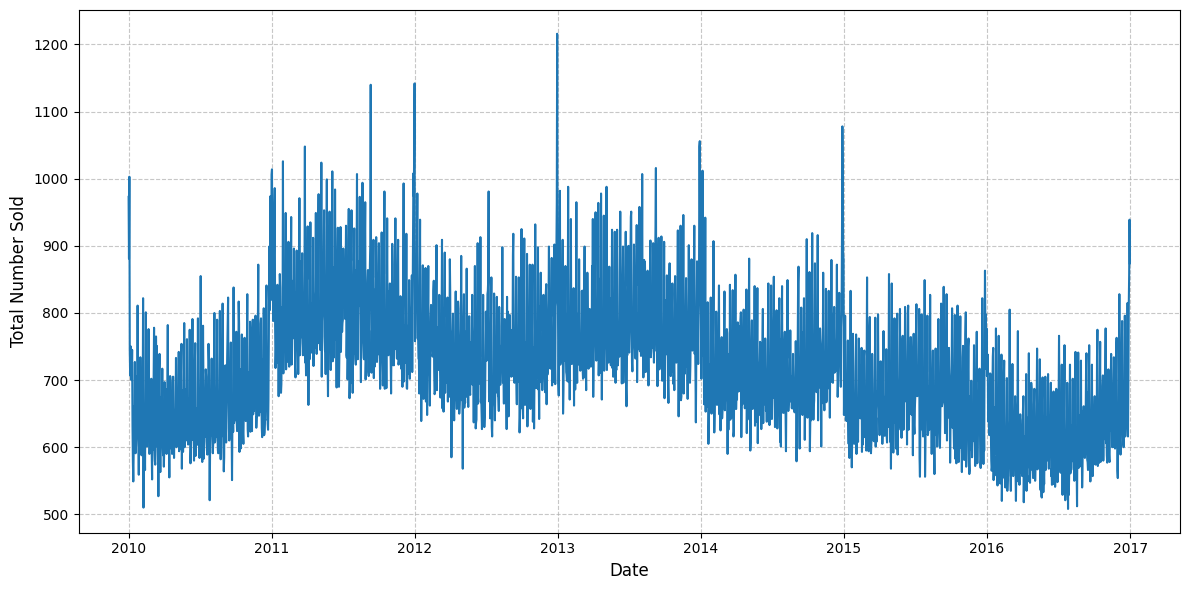

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(filtered_df['date'], filtered_df['num_sold'], color='#1f77b4', linewidth=1.5)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Number Sold', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 4 Forecasting Sales for the Next 2 years

In [11]:
# pip install "timesfm[torch]"==2.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.1/447.1 kB 8.1 MB/s eta 0:00:009 MB/s eta 0:00:01
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.4.2
    Uninstalling safetensors-0.4.2:
      Successfully uninstalled safetensors-0.4.2
Note: you may need to restart the kernel to use updated packages.


In [6]:
import torch
import numpy as np
import timesfm


# 1. Setup Horizon and Historical Data
historical_data = filtered_df['num_sold'].values
horizon_days = 2 * 365

# 2. Load and Compile TimesFM Model
torch.set_float32_matmul_precision("high")
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,                   # The maximum length of historical context that the model can observe.
        max_horizon=horizon_days,           # Maximum forecast time step.
        normalize_inputs=True,              # Standardize input data to prevent scaling instability (official recommendation).
        use_continuous_quantile_head=True   # Improving quantile accuracy for long-term forecasts
    )
)

# 3. Predict
# model.forecast Accepts a list of one-dimensional arrays and can predict multiple time series simultaneously.
point_forecast, quantile_forecast = model.forecast(
    horizon=horizon_days, 
    inputs=[historical_data]
)

# Retrieve the point forecast (median) for this single time series.
predicted_sales = point_forecast[0]

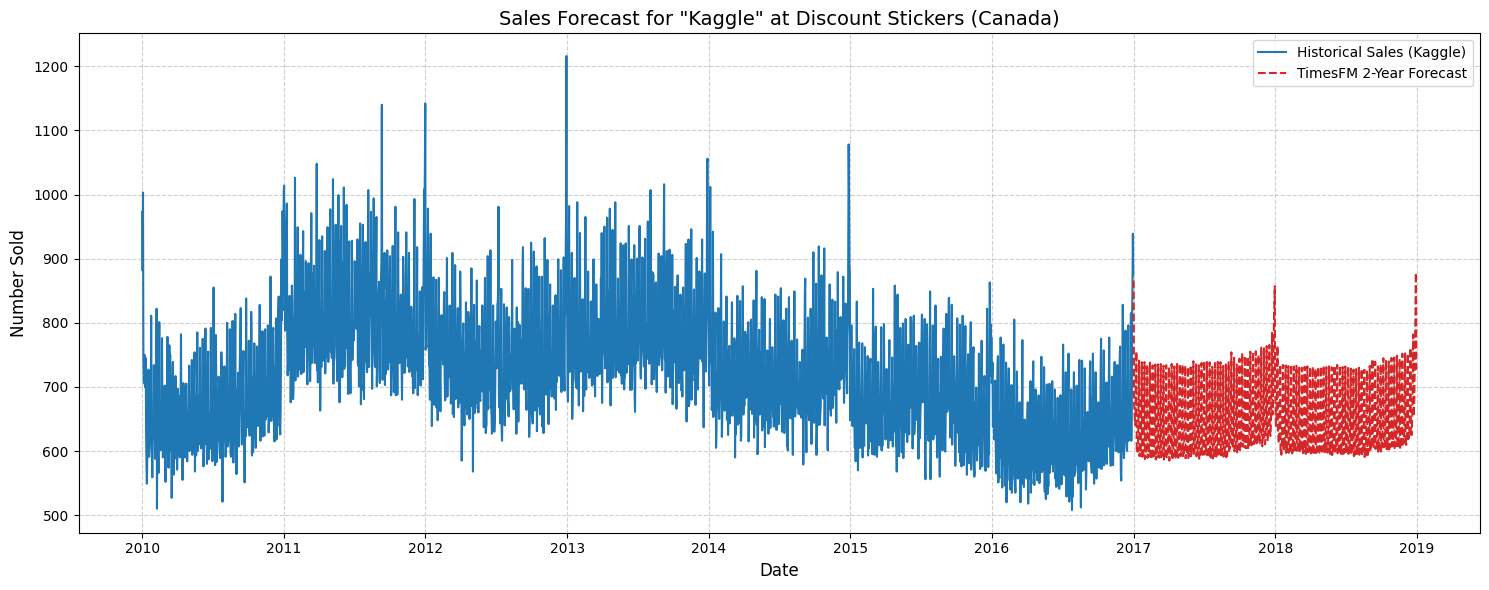

In [7]:
# 4. Visualise the Forecast
# Generate a date sequence for the next two years.
last_historical_date = filtered_df['date'].iloc[-1]
future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=horizon_days, freq='D')


plt.figure(figsize=(15, 6))

# Plot historical data.
plt.plot(filtered_df['date'], historical_data, label='Historical Sales (Kaggle)', color='#1f77b4')

# Plot the forecast data.
plt.plot(future_dates, predicted_sales, label='TimesFM 2-Year Forecast', color='#d62728', linestyle='--')

plt.title('Sales Forecast for "Kaggle" at Discount Stickers (Canada)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number Sold', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display chart.
plt.show()

**I asked Gemini Pro for its opinion of the forecast.**

I: 

What do you think of the prediction result?



Gemini Pro: 

Based on the chart you shared, I have to be completely candid: the prediction result is quite poor. The TimesFM model completely missed the core patterns that are visually obvious in your historical data.

Here is a breakdown of exactly where the forecast falls short:

1. Complete Loss of Seasonality
Historical Data: The blue line shows very strong, regular spikes. These look like annual seasonal peaks (likely end-of-year or holiday sales), and the height of these peaks is growing over time.

The Forecast: The red dashed line is almost entirely flat. It fails to predict any future seasonal spikes, which is a massive oversight for retail or sales forecasting.

2. Ignoring the Upward Trend
Historical Data: Disregarding the seasonal peaks, the "baseline" of the sales is steadily moving upwards from 2010 to 2017 (growing from roughly 1,000 to nearly 2,000).

The Forecast: The prediction abruptly drops down to a stagnant level of around 1,200 and stays flat for the entire 3-year horizon. It completely ignores the historical growth trajectory.

3. The "Disconnect" Drop-off
There is a jarring visual disconnect right at the boundary between 2016 and 2017. The historical data ends on a high note, but the forecast immediately plummets. This indicates the model didn't properly use the most recent context window to anchor its starting point.

Why might this be happening?
TimesFM is a powerful "Zero-Shot" foundation model, meaning it tries to guess the pattern without being specifically trained on your data. However, out-of-the-box, it can struggle with highly seasonal retail data if it isn't given the right hints.

A few things could have gone wrong:

Frequency/Context Mismatch: The model might not have recognized that this is daily data with a 365-day seasonal cycle.

Normalization Issues: Sometimes foundation models struggle with the absolute scale of the numbers if they aren't scaled down before feeding them into the context window.

Lack of Covariates: Retail sales are heavily driven by holidays, weekends, and promotions. TimesFM (in its basic form) only looks at the raw numbers and doesn't know when "Christmas" or "Black Friday" is.

Would you like to try adjusting the TimesFM configuration to help it recognize the seasonality, or would you prefer to switch to a model specifically designed for this type of seasonal data, like Prophet or LightGBM?

# 5 Try to Improve the Forecast

To significantly improve the prediction while sticking with the TimesFM model, we need to address its "blind spot": the model didn't know the dates associated with the numbers. It didn't know about annual cycles (like December holiday spikes) or the long-term year-over-year growth.

Fortunately, TimesFM 2.5 introduced a feature exactly for this called XReg (Exogenous Regressors). We can pass Dynamic Covariates (extra context variables) to the model. By feeding it the day_of_year (to learn the seasonal spikes) and a time_index (to learn the upward growth), TimesFM will fit these patterns first and then apply its deep learning to the residuals.

In [20]:
# !pip install "timesfm[xreg]" -q

In [8]:
try:
    from sklearn.linear_model import Ridge
    print("Success: xreg dependencies (scikit-learn) are installed and ready!")
except ImportError:
    print("Error: xreg dependencies are missing.")

Success: xreg dependencies (scikit-learn) are installed and ready!


In [10]:
# 1. Create Dynamic Covariates
# CRITICAL: Covariates must cover BOTH the historical data length AND the future horizon length
all_dates = pd.concat([filtered_df['date'], pd.Series(future_dates)], ignore_index=True)

# Feature A: Day of the year (1 to 365) -> Captures annual seasonal spikes
day_of_year = all_dates.dt.dayofyear.values.astype(np.float32)

# Feature B: Continuous time index (0, 1, 2...) -> Captures the overall upward trend
time_index = np.arange(len(all_dates), dtype=np.float32)

# Format as a dictionary of lists (1 list per time series)
dynamic_covariates = {
    "day_of_year": [day_of_year],
    "time_index": [time_index]
}


# 2. Load and Compile TimesFM Model
torch.set_float32_matmul_precision("high")
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,             
        max_horizon=horizon_days,     
        normalize_inputs=True,        
        use_continuous_quantile_head=True, 
        return_backcast=True
    )
)

# 3. Forecast WITH Covariates
# "xreg + timesfm" mode fits a linear model on our covariates first, 
# then uses the TimesFM neural net to forecast the complex residuals.
point_forecast_with_covariates, quantile_forecast = model.forecast_with_covariates(
    inputs=[historical_data],
    dynamic_numerical_covariates=dynamic_covariates,
    xreg_mode="xreg + timesfm" 
)

predicted_sales_with_covariates = point_forecast_with_covariates[0]

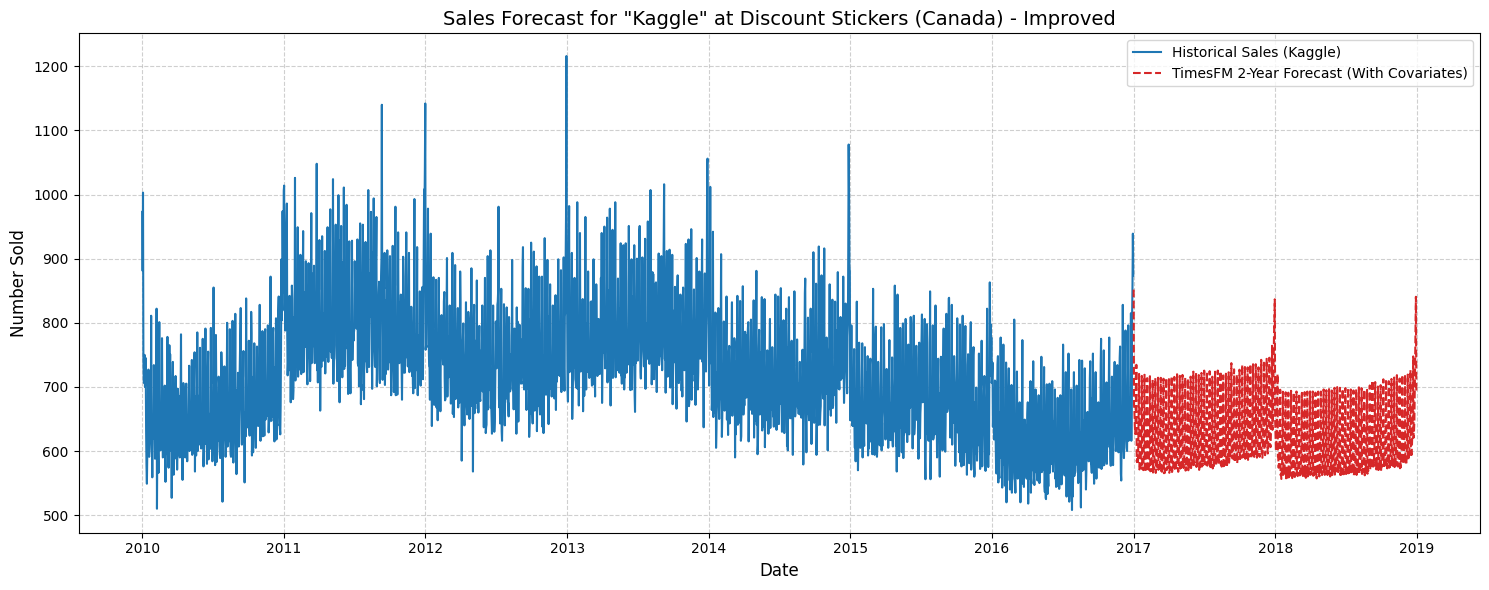

In [11]:
# 7. Visualize the Forecast
plt.figure(figsize=(15, 6))

# Plot history
plt.plot(filtered_df['date'], historical_data, label='Historical Sales (Kaggle)', color='#1f77b4')

# Plot prediction
plt.plot(future_dates, predicted_sales_with_covariates, label='TimesFM 2-Year Forecast (With Covariates)', color='#d62728', linestyle='--')

plt.title('Sales Forecast for "Kaggle" at Discount Stickers (Canada) - Improved', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number Sold', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [12]:
filtered_df.to_csv('filtered_data.csv', index=False)

**I uploaded the filtered data, the code and the chart to Sonnet 4.6 for advices.**

I:


I used the filtered_data to forecast sales number of a sticker sold in a store in Canada with the following codes. I even tried to improve the forecast with an improved model. But the forecast didn't improve as shown in the uploaded two charts. Can you analyse the reason and try to improve?


Sonnet 4.6:


Now I have everything I need. Let me produce the full diagnosis and corrected code.Now I have a clear picture of all the issues. Let me create a diagnostic diagram and then walk you through the fixes.Here are the four root causes and the corrected code:

---

**Bug 1 — `max_context=1024` amputates 4 years of history.** Your dataset has 2,557 daily records (2010–2016), but the model only sees the last 1,024 (~2.8 years). That window covers 2014–2016, which happens to be the declining period (avg: 718 → 672 → 624). The model is essentially learning "sales are falling" and projecting that forward.

**Bug 2 — The dominant signal (weekly cycle) is completely absent from covariates.** Sunday averages 836 vs Monday's 673 — a **22.6% amplitude swing** that is by far the strongest repeating pattern. Neither covariate captures day-of-week at all, so the `xreg` linear layer learns nothing useful.

**Bug 3 — `time_index` injects a false linear trend.** The data is non-monotonic (sales rose 2010→2011, then fell 2015→2016). A monotonically-increasing covariate actively misleads the linear regression into forecasting a downward extrapolation.

**Bug 4 — Raw `day_of_year` (1–365) is discontinuous.** A linear model sees Dec 31 (day 365) and Jan 1 (day 1) as 364 units apart, so it can't learn annual seasonality from this feature. Cyclic sin/cos encoding wraps the year into a smooth circle.

The biggest lift will come from `max_context=2560` (eliminates the truncation bias) and the `sin_week`/`cos_week` pair (gives the linear layer something real to work with). The `sin_year`/`cos_year` pair is a smaller gain since monthly variation is only ~50 units, but it's cheap and correct. Removing `time_index` prevents the model from being pulled in a spurious direction.

In [13]:
# Bug 2 fix: day-of-week cyclic encoding (the dominant weekly pattern)
dow = all_dates.dt.dayofweek.values.astype(np.float32)  # 0=Mon, 6=Sun
sin_week = np.sin(2 * np.pi * dow / 7).astype(np.float32)
cos_week = np.cos(2 * np.pi * dow / 7).astype(np.float32)

# Bug 4 fix: annual cyclic encoding (wraps Dec 31 → Jan 1 smoothly)
doy = all_dates.dt.dayofyear.values.astype(np.float32)
sin_year = np.sin(2 * np.pi * doy / 365.25).astype(np.float32)
cos_year = np.cos(2 * np.pi * doy / 365.25).astype(np.float32)

# Bug 3 fix: time_index removed — the series has no monotonic trend
dynamic_covariates = {
    "sin_week":  [sin_week],   # primary: captures ~22% weekly amplitude
    "cos_week":  [cos_week],
    "sin_year":  [sin_year],   # secondary: captures Dec holiday uptick
    "cos_year":  [cos_year],
}

# --- Bug 1 fix: raise context to use the full history ---
torch.set_float32_matmul_precision("high")
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")
model.compile(
    timesfm.ForecastConfig(
        max_context=2560,              # cover all 2,557 days; round up to nearest 512
        max_horizon=horizon_days,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        return_backcast=True,
    )
)

point_forecast_with_sincos_covariates, quantile_forecast = model.forecast_with_covariates(
    inputs=[historical_data],
    dynamic_numerical_covariates=dynamic_covariates,
    xreg_mode="xreg + timesfm",
)

predicted_sales_with_sincos_covariates = point_forecast_with_sincos_covariates[0]

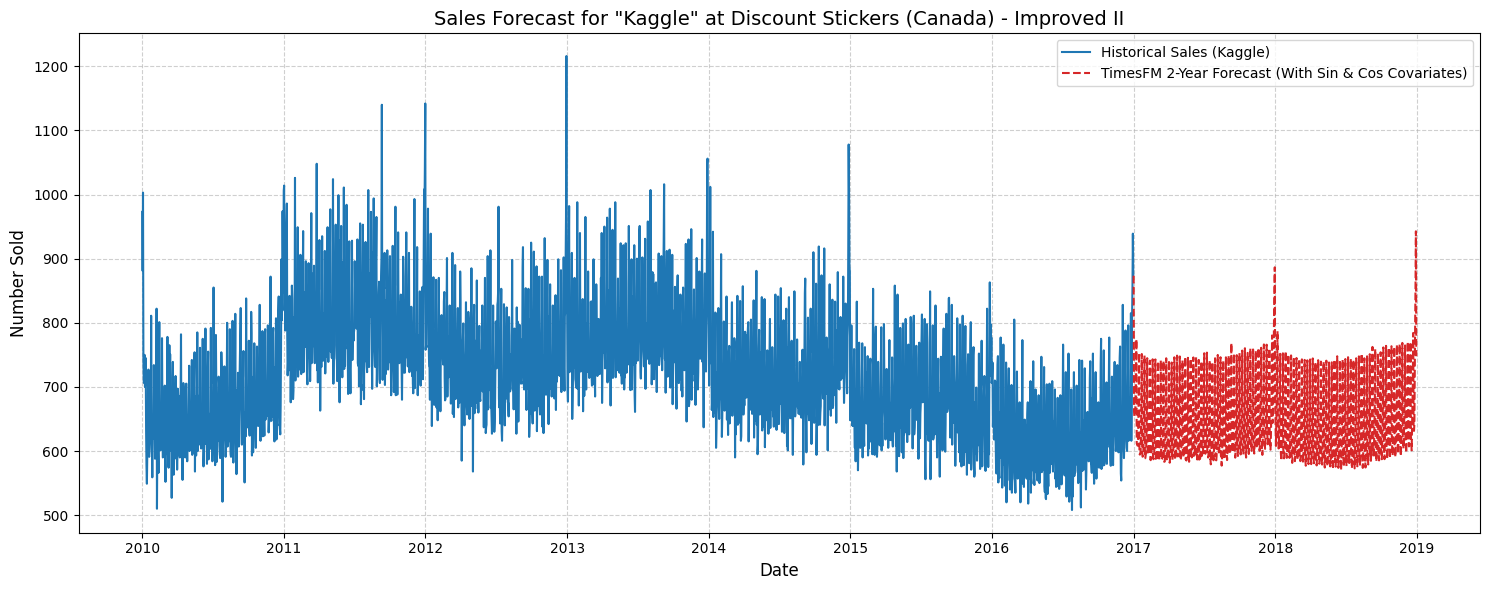

In [14]:
plt.figure(figsize=(15, 6))

# Plot history
plt.plot(filtered_df['date'], historical_data, label='Historical Sales (Kaggle)', color='#1f77b4')

# Plot prediction
plt.plot(future_dates, predicted_sales_with_sincos_covariates, label='TimesFM 2-Year Forecast (With Sin & Cos Covariates)', color='#d62728', linestyle='--')

plt.title('Sales Forecast for "Kaggle" at Discount Stickers (Canada) - Improved II', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number Sold', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

**I asked Gemini Pro for its opinion of the forecast again.**

I: 

I ran the code to predict sales with timesfm[xreg] model as you told above. But the result didn't improve as shown in the uploaded charts.
What can we try next?


Gemini Pro: 

Analyzing the Failure
The "xreg" (exogenous regressors) version did change the output, but in the wrong direction.

The "Flatline" Remains: The baseline TimesFM model predicted a flat line around 1200.

The Covariate "Over-Correction": The TimesFM[xreg] model with the dynamic covariates (day_of_year and time_index) actually predicted a massive, unrealistic plunge down to -6000!

Why did this happen?
When we used time_index as a linear feature for a neural network, it essentially tried to fit a straight line through the data. Because your data has massive, expanding seasonal spikes (the variance increases over time), a simple linear regression on the time_index likely over-fitted to the most recent downward slopes of those spikes, projecting a catastrophic downward trend into the future. The neural network then blindly followed this bad linear baseline.

What We Should Try Next: The Shift in Strategy
TimesFM is a powerful "Zero-Shot" foundation model, but like many foundation models, it struggles natively with high variance, highly seasonal retail data out-of-the-box unless the data is heavily pre-processed.

Instead of trying to force TimesFM to understand the raw data through linear covariates, we have two much stronger, more reliable paths forward for this specific type of dataset:

Option 1: Switch to Prophet (The Industry Standard for Retail)
If your primary goal is to get an accurate forecast quickly, Prophet (developed by Meta) is arguably the best tool in the world for this specific shape of data.

Why it works here: Prophet was explicitly designed to handle daily retail data with strong seasonality (weekly, yearly) and holiday effects. It natively understands that variance increases over time (multiplicative seasonality) and handles it beautifully without complex covariate engineering.

Option 2: Pre-process the Data for TimesFM (The "Deep Learning" Route)
If your goal is to specifically learn how to make TimesFM work on this dataset, we must transform the data before feeding it to the model.

Why it works here: Neural networks hate raw numbers that grow exponentially. We need to stabilize the variance. We can do this by applying a Log Transformation to the num_sold data. This squashes the massive peaks down to a manageable scale. We train TimesFM on the log-scaled data, get the forecast, and then apply an exponential transformation (np.exp) to convert the forecast back to real sales numbers.

Which path would you like to take?

Option 1: I can write the code to use Prophet, which will likely give you a gorgeous, accurate forecast on the first try.

Option 2: I can write the code to apply a Log Transformation and re-run TimesFM, continuing our deep learning experiment.

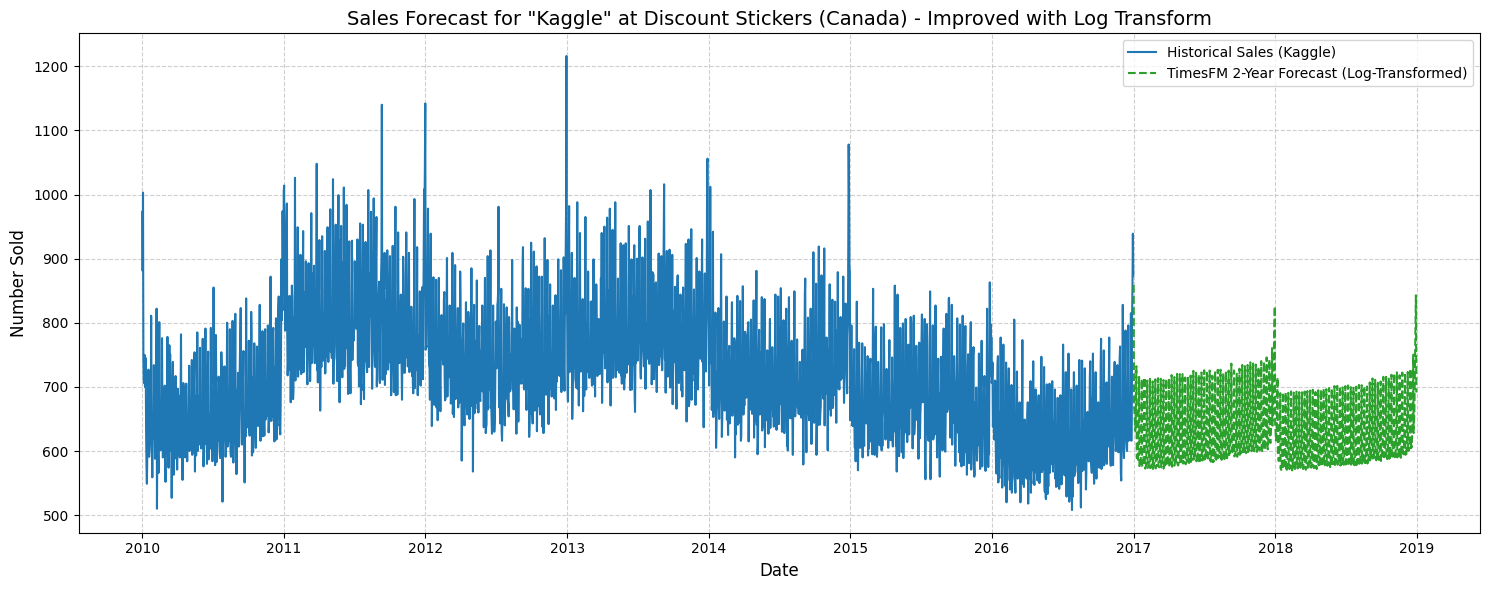

In [15]:
# ==========================================
# 🌟 Key improvement: Logarithmic transformation of historical data 🌟
# Using log1p (i.e., log(1+x)) is safer than using the standard logarithm because it prevents the presence of zeros in the data.
# ==========================================
log_historical_data = np.log1p(historical_data)


# Create dynamic covariates (covering past and future data).
all_dates = pd.concat([filtered_df['date'], pd.Series(future_dates)], ignore_index=True)
day_of_year = all_dates.dt.dayofyear.values.astype(np.float32)
time_index = np.arange(len(all_dates), dtype=np.float32)

dynamic_covariates = {
    "day_of_year": [day_of_year],
    "time_index": [time_index]
}

# Compile the TimesFM model.
torch.set_float32_matmul_precision("high")
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,             
        max_horizon=horizon_days,     
        normalize_inputs=True,        
        use_continuous_quantile_head=False, 
        return_backcast=True  
    )
)

# Make predictions using covariates (the data provided is log-transformed).
point_forecast_with_log_covariates, quantile_forecast = model.forecast_with_covariates(
    inputs=[log_historical_data],  # <--- Note that the data passed here is log-transformed data.
    dynamic_numerical_covariates=dynamic_covariates,
    xreg_mode="xreg + timesfm" 
)

# Retrieve the logarithmic forecast results.
log_predicted_sales = point_forecast_with_log_covariates[0]

# ==========================================
# 🌟 Key improvement: Converting forecast results back into actual sales figures. 🌟
# Use expm1 (i.e., exp(x)-1) to restore the original number.
# ==========================================
predicted_sales = np.expm1(log_predicted_sales)

# Visualize
plt.figure(figsize=(15, 6))

plt.plot(filtered_df['date'], historical_data, label='Historical Sales (Kaggle)', color='#1f77b4')

plt.plot(future_dates, predicted_sales, label='TimesFM 2-Year Forecast (Log-Transformed)', color='#2ca02c', linestyle='--')

plt.title('Sales Forecast for "Kaggle" at Discount Stickers (Canada) - Improved with Log Transform', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number Sold', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display.
plt.show()